## Biodiversity data


In [1]:

import geopandas as gpd
import pandas as pd


#Read in shapefile tags
ahp = gpd.read_file("/fs9/eliviau/hex2vec_project/land_use_framework/data/biodiversity_tags") #specify which tags to use


In [2]:
ahp.head()

,feature_id,latitude,longitude,satoyama,geometry
0,0,24.516667,122.875,10.0,"POLYGON ((122.875 24.51667, 123 24.51667, 123 ..."
1,1,24.100000,123.750,2.0,"POLYGON ((123.75 24.1, 123.875 24.1, 123.875 2..."
2,2,24.266667,123.875,7.0,"POLYGON ((123.875 24.26667, 124 24.26667, 124 ..."
3,3,24.350000,123.625,3.0,"POLYGON ((123.625 24.35, 123.75 24.35, 123.75 ..."
4,4,24.350000,123.750,5.0,"POLYGON ((123.75 24.35, 123.875 24.35, 123.875..."


In [3]:
ahp["satoyama"].unique()

array([10.,  2.,  7.,  3.,  5.,  8.,  6.,  9., 11.,  1.,  4., 13., 12.,
        0., 14.])

In [4]:
from srai.regionalizers import geocode_to_region_gdf

# Step 1: Get the boundary for Yamagata prefecture
area = geocode_to_region_gdf("Hokkaido, Japan")
area.crs  # should return EPSG:4326

/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [5]:
area.head()

,geometry
region_id,
"Hokkaido Prefecture, Japan","POLYGON ((139.06728 41.51453, 139.06751 41.506..."


In [6]:
from srai.regionalizers import H3Regionalizer

# Step 2: Create H3 hexagons for Yamagata
regionalizer = H3Regionalizer(resolution=7)  # resolution 9 = ~500m hexes
regions = regionalizer.transform(area)

regions.head()

,geometry
region_id,
872ef4316ffffff,"POLYGON ((141.22874 43.92036, 141.22449 43.932..."
872ef4a4cffffff,"POLYGON ((141.00383 43.55019, 140.99957 43.562..."
872e1e571ffffff,"POLYGON ((143.78406 42.63131, 143.78025 42.643..."
872e192a2ffffff,"POLYGON ((140.42109 41.9826, 140.41685 41.9947..."
872e1c4c9ffffff,"POLYGON ((143.16195 41.84055, 143.15809 41.853..."


In [7]:
regions.shape

(28902, 1)

step 3 : join 

In [8]:
from srai.joiners import IntersectionJoiner

# Make sure CRS matches!
ahp = ahp.to_crs(regions.crs)

# Step 3: Use IntersectionJoiner to match land cover to hexagons
joiner = IntersectionJoiner()
joined = joiner.transform(regions, ahp)

# Preview the result
joined.head()


,
region_id,feature_id
872ee4c46ffffff,3624
872ee4c2bffffff,3624
872ee4c73ffffff,3624
872ee4c72ffffff,3624
872ee4c42ffffff,3624


In [9]:
joined.shape

(29193, 0)

In [10]:
# Bring region_id back as a column
joined = joined.reset_index()

# Now merge safely
joined_with_tags = joined.merge(
    ahp[["feature_id", "satoyama"]],
    on="feature_id",
    how="left"
)

In [11]:
joined_with_tags.head()

,region_id,feature_id,satoyama
0,872ee4c46ffffff,3624,7.0
1,872ee4c2bffffff,3624,7.0
2,872ee4c73ffffff,3624,7.0
3,872ee4c72ffffff,3624,7.0
4,872ee4c42ffffff,3624,7.0


In [12]:
ahp_score = {
    0: 10,
    1: 9,
    2: 9,
    3: 8,
    4: 7,
    5: 6,
    6: 5,
    7: 4,
    8: 3,
    9: 2,
    10: 1,
    11: 1,
    12: 0,
    13: 0,
    14: 0
}

In [13]:
joined_with_tags["ahp_score"] = joined_with_tags["satoyama"].map(ahp_score)


In [14]:
ahp.head()

,feature_id,latitude,longitude,satoyama,geometry
0,0,24.516667,122.875,10.0,"POLYGON ((122.875 24.51667, 123 24.51667, 123 ..."
1,1,24.100000,123.750,2.0,"POLYGON ((123.75 24.1, 123.875 24.1, 123.875 2..."
2,2,24.266667,123.875,7.0,"POLYGON ((123.875 24.26667, 124 24.26667, 124 ..."
3,3,24.350000,123.625,3.0,"POLYGON ((123.625 24.35, 123.75 24.35, 123.75 ..."
4,4,24.350000,123.750,5.0,"POLYGON ((123.75 24.35, 123.875 24.35, 123.875..."


In [15]:
joined_with_tags["ahp_score"] = joined_with_tags["satoyama"].map(ahp_score)


In [16]:
hex_scores = joined_with_tags.groupby("region_id")["ahp_score"].mean().reset_index()
hex_scores.columns = ["region_id", "ahp_score"]


In [17]:
# Merge scores into hexagon GeoDataFrame
regions_scored = regions.merge(hex_scores, on="region_id", how="left")


In [18]:
regions_scored.head(30)

,region_id,geometry,ahp_score
0,872e1bca5ffffff,"POLYGON ((141.77841 42.96173, 141.77429 42.973...",9.0
1,872e8db45ffffff,"POLYGON ((141.92596 45.54248, 141.9217 45.5545...",2.0
2,872eac323ffffff,"POLYGON ((144.89233 43.67554, 144.88862 43.688...",3.0
3,872e1ea0affffff,"POLYGON ((143.11584 42.12956, 143.11196 42.142...",6.0
4,872e192ecffffff,"POLYGON ((140.17834 41.90276, 140.17407 41.914...",4.0
5,872ead633ffffff,"POLYGON ((143.72256 43.89045, 143.71867 43.902...",3.5
6,872ead043ffffff,"POLYGON ((143.66997 43.48233, 143.66609 43.494...",4.0
7,872ead32dffffff,"POLYGON ((143.441 43.35384, 143.4371 43.36624,...",1.0
8,872e1e2d1ffffff,"POLYGON ((142.84182 42.62691, 142.83787 42.639...",NaN
9,872e1a818ffffff,"POLYGON ((142.71139 42.89614, 142.70741 42.908...",7.0


In [19]:
#regions_scored save to output
regions_scored.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_biodiversityreso7.geojson", driver="GeoJSON")

In [20]:
from srai.plotting import plot_numeric_data

#remettre le index 
regions_scored = regions_scored.set_index("region_id")

m = plot_numeric_data(regions_scored, "ahp_score", colormap="Greens", opacity=0.6)
m.save("biodiversity_hokkaido_map.html")


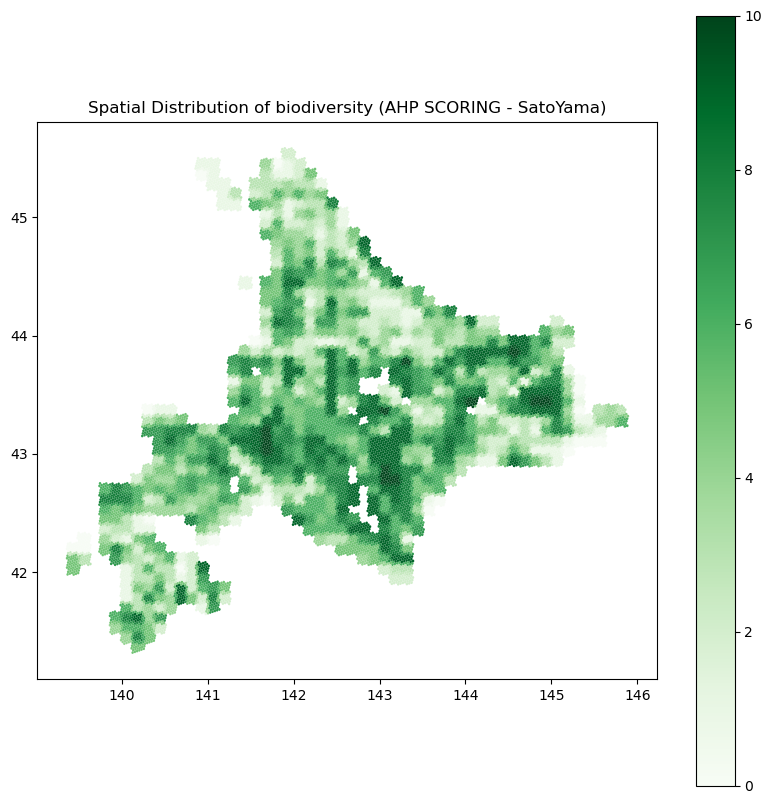

In [21]:
#other map 

#other quickmap 
# If you still have 'regions' geodataframe loaded:


from matplotlib import pyplot as plt


regions_scored.plot(
    column='ahp_score',
    cmap='Greens',
    legend=True,
    figsize=(10,10)
)
plt.title("Spatial Distribution of biodiversity (AHP SCORING - SatoYama)")
plt.show()


/tmp/ipykernel_54472/1640623685.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


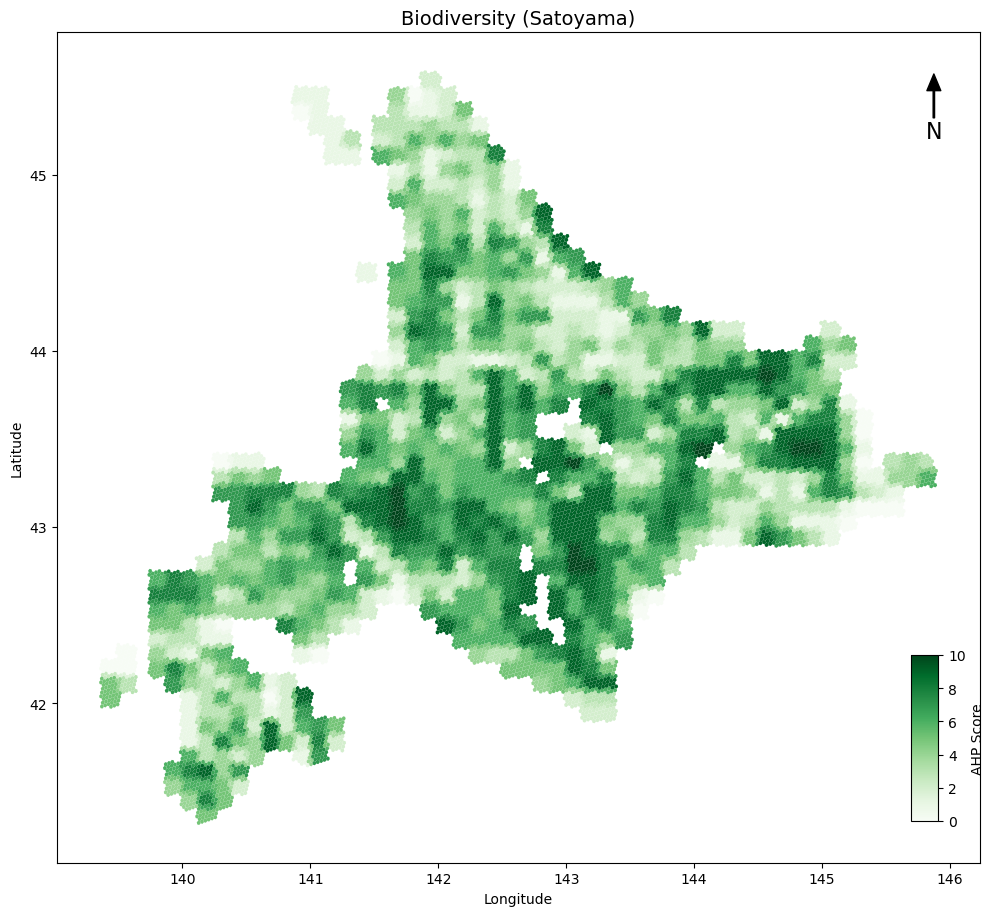

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# 1. Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot main map
main_plot = regions_scored.plot(
    column='ahp_score',
    cmap='Greens',
    legend=False,  # We'll add a custom one
    ax=ax,
    edgecolor='none'
)

# 3. Add colorbar INSIDE the plot area
sm = plt.cm.ScalarMappable(cmap='Greens', norm=plt.Normalize(vmin=regions_scored['ahp_score'].min(), vmax=regions_scored['ahp_score'].max()))
sm._A = []

cax = inset_axes(ax, width="3%", height="20%", loc='lower right', borderpad=3)  # Adjust size/position here
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label("AHP Score")

# 4. Coordinate grid and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Biodiversity (Satoyama)", fontsize=14)

# Add north arrow but arrow shorter
ax.annotate('N',
            xy=(0.95, 0.95), xytext=(0.95, 0.88),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16,
            arrowprops=dict(facecolor='black', width=1, headwidth=10)) 

plt.tight_layout()
plt.show()
